prof. dr Mirna Radović, Stefan Topalov,

Decembar 2024.

# Optimizacija rojem čestica



Algoritam optimizacije rojem čestica (PSO algoritam), koji je razvijen za pronalaženje
optimalnih rešenja optimizacionih problema, oslanja se na interakciju
među jedinkama unutar određene populacije. Utemeljen je 1995. godine od
strane istraživača Džejmsa Kenedija i Rasela Eberharta. Inspirisani
idejom sociobiologa da jedinke u jatima riba ili ptica mogu imati koristi od iskustava i saznanja drugih članova grupe, posebno u traženju hrane, pokušali su da modeluju i simuliraju socijalno ponašanje ptica
u jatima. Analogno ovom prirodnom fenomenu, PSO algoritam oslikava saradnju čestica (jedinki) koje čine roj (populaciju).

Iterativno menjajući poziciju i brzinu čestica, algoritam pretražuje prostor rešenja u cilju pronalaženja globalnog optimuma
 kriterijuma optimalnosti 𝑓(𝑥). Svaka čestica predstavlja potencijalno
 rešenje problema, i u svakoj iteraciji je karakterišu sledeći parametri:

*   Trenutna pozicija čestice, 𝑥[𝑘] = ($𝑥_1[𝑘],𝑥_2[𝑘],...,𝑥_𝑛[𝑘]$). Predstavlja koordinate tačke u kojoj se čestica trenutno nalazi.
*   Trenutna brzina čestice, 𝑣[𝑘] = ($𝑣_1[𝑘],𝑣_2[𝑘],...,𝑣_𝑛[𝑘]$).

*   Najbolja sopstvena pozicija čestice,
 𝑝[𝑘] = ($𝑝_1[𝑘], 𝑝_2[𝑘],..., 𝑝_𝑛[𝑘]$). Predstavlja poziciju čestice u kojoj je,
 do trenutne iteracije, posmatrana čestica imala najbolju vrednost
 kriterijuma optimalnosti.

*   Najbolja sopstvena vrednost kriterijuma optimalnosti $𝑝_{best}$

Parametri koji karakterišu roj u svakoj iteraciji su:


*   Najbolja globalna pozicija (engl. global best position)
 𝑔[𝑘] = ($𝑔_1[𝑘],𝑔_2[𝑘],...,𝑔_𝑛[𝑘]$). Predstavlja poziciju u kojoj je, do trenutne iteracije, ostvarena najbolja vrednost kriterijuma optimalnosti, na nivou celog roja.
*   Najbolja globalna vrednost kriterijuma optimalnosti $𝑔_{best}$

 Gde je 𝑘 broj tekuće iteracije, a 𝑛 dimenzionalnost prostora.



 Kretanje čestica u roju može se i matematički definisati. U svakoj
 iteraciji potrebno je izračunati novu vrednost brzine kretanja čestice i
 njenu novu poziciju u roju,

 \begin{align}
v[k+1]&=w \cdot v[k]+cp \cdot rp[k] (p_{best}[k]-x[k])+cg \cdot rg[k](g_{best}[k]-x[k])\\
x[k+1]&=x[k]+v[k+1]
\end{align}

 gde su 𝑟𝑝[𝑘] i 𝑟𝑔[𝑘] slučajni brojevi iz opsega [0,1]. Koeficijent 𝑤 je
 koeficijent inercije, dok su 𝑐𝑝 i 𝑐𝑔 koeficijenti ubrzanja.

 Može se primetiti da se izraz za računanje brzine čestice sastoji od tri komponente:


*   Inercijalna komponenta je određena koeficijentom 𝑤 i pod njenim uticajem čestica nastavlja da se kreće u pravcu u kom se i do
 tada kretala.
*   Kognitivna komponenta je određena koeficijentom 𝑐𝑝 i ona usmerava česticu u pravcu sopstvenih saznanja, odnosno ka najboljoj sopstvenoj vrednosti kriterijuma optimalnosti.

*   Socijalna komponenta je određena koeficijentom 𝑐𝑔 i ona usmerava česticu ka najboljoj globalnoj vrednosti kriterijuma optimalnosti. Ova komponenta oslikava saradnju između čestica u roju.

PSO algoritam se sastoji od sledećih koraka:

1. Inicijalizacija: Postavljanje parametara algoritma kao što su broj iteracija, broj čestica, nasumično postavljanje početnih pozicija čestica, nasumično postavljanje početnih brzina čestica, itd.
2. Optimizacija - koraci iteracije:
*   Ocena prilagodljivosti svake čestice, tj. izračunavanje vrednosti kriterijuma optimalnosti svake čestice

*   Ažuriranje najboljih ličnih i najboljnih globalnih prilagodljivosti i pozicija  
*   Ažuriranje brzine i pozicije svake čestice



    
3.  Provera kriterijuma zaustavljanja




# Implementacija PSO algoritma

In [1]:
# Load basic numeric packages
import numpy as np
import random as random
import math as math
import matplotlib.pyplot as plt


In [2]:
#This class defines default values of the options within the options structure.
class myOptions:
    def __init__(self):
        self.npart          = 30;       # The number of particles.
        self.niter          = 100;      # The number of iterations.
        self.cbi            = 2.5;      # Initial value of the individual-best acceleration factor.
        self.cbf            = 0.5;      # Final value of the individual-best acceleration factor.
        self.cgi            = 0.5;      # Initial value of the global-best acceleration factor.
        self.cgf            = 2.5;      # Final value of the global-best acceleration factor.
        self.wi             = 0.9;      # Initial value of the inertia factor.
        self.wf             = 0.4;      # Final value of the inertia factor.
        self.vmax           = math.inf;      # Absolute speed limit. It is the primary speed limit.
        self.vmaxscale      = float('nan');      #Relative speed limit. Used only if absolute limit is unspecified.
        self.vspaninit      = 1;        # The initial velocity span. Initial velocities are initialized
        self.initpopulation = float('nan');
        self.initoffset     = 0;        # Offset of the initial population.
        self.initspan       = 1;        # Span of the initial population.
        self.trustoffset    = 0;        # If set to 1 (true) and offset is vector, than the offset is
                                        # believed to be a good solution candidate, so it is included in
                                        # the initial swarm.

In [3]:
class Error(Exception):
    def __init__(self, message):
        self.message = message

In [4]:
class Particle:
    def __init__(self,x0,num_dimensions,options):
        self.position_i=[]          # particle position
        self.velocity_i=[]          # particle velocity
        self.pos_best_i=[]          # best position individual
        self.fitness_best_i=-1          # best fitness individual
        self.fitness_i=-1               # fitness individual
        self.num_dimensions=num_dimensions

        # Initial positions and velocities
        for i in range(0,num_dimensions):
            self.velocity_i.append((np.random.rand()-0.5)*2*options.vspaninit)
            self.position_i.append(x0[i][0])

    # calculate current fitness and calculate new individual best values
    def evaluate(self,costFunc):
        self.fitness_i=costFunc(self.position_i)
        # update individual best -> check if the current position is better than the individual best
        if self.fitness_i < self.fitness_best_i or self.fitness_best_i==-1:
            self.pos_best_i=np.copy(self.position_i)
            self.fitness_best_i=np.copy(self.fitness_i)


    def linrate(self,xmax, xmin, tmax, tmin, t):
        x = xmin + ((xmax-xmin)/(tmax-tmin))*(tmax-t)
        return x

    # calculate new particle velocity
    def update_velocity(self,pos_best_g,maxiter,iter,opt):

        # Calculate PSO parameters
        w = self.linrate(opt.wf, opt.wi, maxiter, 0, iter);
        cp = self.linrate(opt.cbf, opt.cbi, maxiter, 0, iter);
        cg = self.linrate(opt.cgf, opt.cgi, maxiter, 0, iter);


        for i in range(0,self.num_dimensions):
            r1=random.random()
            r2=random.random()
            # Calculating velocities
            vel_cognitive=cp*r1*(self.pos_best_i[i]-self.position_i[i])
            vel_social=cg*r2*(pos_best_g[i]-self.position_i[i])
            self.velocity_i[i]=w*self.velocity_i[i]+vel_cognitive+vel_social

    # update the particle position based off new velocity updates->moving particle
    def update_position(self):
        for i in range(0,self.num_dimensions):
            self.position_i[i]=self.position_i[i]+self.velocity_i[i]



In [5]:
class PSO():
    def __init__(self,costFunc,num_dimensions,options):
        self.pos_best_g=[]
        self.fitness_best_g=-1
        fitness_best_g=-1                   # best fitness in population
        pos_best_g=[]                      # best position in population

        maxiter=options.niter
        num_particles=options.npart
        population=[]
        if ((~np.isnan(options.initpopulation)).all()):
            b=np.shape(options.initpopulation)
            if(np.size(b)==1):
                pno=b[0]
                pdim=1
            if (pno!=options.npart) or (pdim!=options.nvar):
                 raise Error("The format of initial population is inconsistent with desired population")
            population=options.initpopulation;
        else:
            for i in range(0,num_particles):
                x0=(np.random.rand(num_dimensions,1)-0.5)*2*options.initspan + options.initoffset
                population.append(Particle(x0,num_dimensions,options))

        #################################
        ###The main loop  ###############
        #################################
        # Begin optimization loop
        i=0
        while i < maxiter:
            #print(i, fitness_best_g)
            #print i,err_best_g
            # cycle through particles in swarm and evaluate fitness
            for j in range(0,num_particles):
                population[j].evaluate(costFunc)

                # Calculating new globally best values (globally)
                if population[j].fitness_i < fitness_best_g or fitness_best_g == -1:
                    pos_best_g=list(population[j].position_i)
                    fitness_best_g=float(population[j].fitness_i)

            # Population is moving-> cycle through population and update velocities and position
            for j in range(0,num_particles):
                population[j].update_velocity(pos_best_g,maxiter,i,options)
                population[j].update_position()
            i+=1
        self.pos_best_g=pos_best_g
        self.fitness_best_g=fitness_best_g
        # print final results
        print( 'Optimal point:')
        print( pos_best_g)
        print( 'Optimal value:')
        print(fitness_best_g)

# Testiranje PSO algoritma


Da bi se testirala efikasnost PSO algoritma, koriste se standardne test funkcije (Ackley, Griewank, Rastrigin, itd.).

Ove test funkcije se često koriste u literaturi kako bi se evaluirala performansa optimizacionih algoritama, uključujući i PSO. Evo nekoliko primera test funkcija.

### Aklijeva (engl. Ackley) funkcija
Aklijeva funkcija se često koristi za testiranje optimizacionih algoritama i opisana je izrazom:
\begin{equation}
f(x)=-a \exp{(-b\sqrt{\frac{1}{d}\sum_{i=1}^d{x^2_i}})}-\exp{(\frac{1}{d}\sum_{i=1}^d\cos{(c x_i)})}+a+\exp(1)
\end{equation}

Dimenzija: d

Preporučene vrednosti promenljivih su: $a = 20$, $b = 0.2$ and $c = 2\pi$.

Globalni Minimum: $f(0, \cdots, 0) = 0$

In [6]:
# Test Functions-Ackley function
def ackley(x):
    sum1=0
    sum2=0
    a=20
    b=0.2
    c=2*math.pi
    d=len(x)
    for i in range(len(x)):
        sum1+=x[i]**2
        sum2+=math.cos(c*x[i])
    total= -a*math.exp(-b*math.sqrt(sum1/d))-math.exp(sum2/d)+a+math.exp(1)
    return total


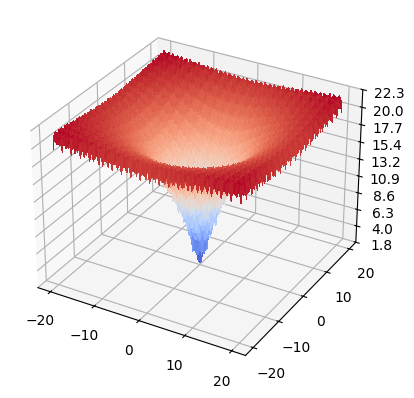

In [7]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plotN = 100
x1 = np.linspace(-20, 20, plotN)
x2 = np.linspace(-20, 20, plotN)
x1, x2 = np.meshgrid(x1,x2)
z=np.zeros(x1.shape)
fig = plt.figure()
for i in range(x1.shape[0]):
    for j in range(x1.shape[1]):
        z[i][j]=ackley([x1[i][j] ,x2[i][j]])
ax = fig.add_subplot(projection='3d')

surf =ax.plot_surface(x1,x2,z, rstride=1, cstride=1, cmap=plt.cm.coolwarm,
        linewidth=0, antialiased=False)

#ax.set_zlim(0, 0.2)

ax.zaxis.set_major_locator(plt.LinearLocator(10))
ax.zaxis.set_major_formatter(plt.FormatStrFormatter('%.01f'))

#fig.savefig('ackley.jpg', format='jpg', dpi=1200)
plt.show()


**Pokretanje** PSO algoritma za pronalazak minimuma petodimenzione Aklijeve funkcije:

In [8]:
options1 = myOptions()
options1.npart=150
options1.niter=300

a=PSO(ackley,5,options=options1)

Optimal point:
[np.float64(1.9732764669949494e-16), np.float64(1.5946459860208721e-15), np.float64(1.7826285178504138e-15), np.float64(9.179339275009222e-18), np.float64(8.776216491636962e-16)]
Optimal value:
3.9968028886505635e-15


### Grivankova funkcija
Grivankova funkcija ima mnogo rasprostranjenih lokalnih minimuma, koji su ravnomerno raspoređeni. Kompleksnost je prikazana na uvećanim dijagramima.
\begin{equation}
f(x) = 1 + \frac{1}{4000} \sum_{i=1}^d x^2_i - \prod_{i=1}^d cos(\frac{x_i}{\sqrt{i}})
\end{equation}

Globalni minimum:
$f(0, \cdots, 0) = 0$

Dimenzija: d

In [9]:
# Test Functions-Griewank  function
def griewank(x):
    sum1=0
    pro2=1

    d=len(x)
    for i in range(len(x)):
        sum1+=x[i]**2
        pro2*=math.cos(x[i]/math.sqrt(i+1))
    total= sum1-pro2+1
    return total

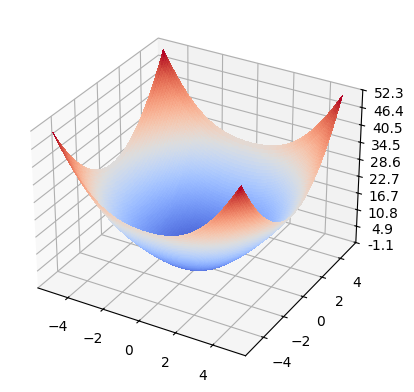

In [10]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plotN = 100
x1 = np.linspace(-5, 5, plotN)
x2 = np.linspace(-5, 5, plotN)
x1, x2 = np.meshgrid(x1,x2)
z=np.zeros(x1.shape)
fig = plt.figure()
for i in range(x1.shape[0]):
    for j in range(x1.shape[1]):
        z[i][j]=griewank([x1[i][j] ,x2[i][j]])
ax = fig.add_subplot(projection='3d')

surf =ax.plot_surface(x1,x2,z, rstride=1, cstride=1, cmap=plt.cm.coolwarm,
        linewidth=0, antialiased=False)

#ax.set_zlim(0, 0.2)

ax.zaxis.set_major_locator(plt.LinearLocator(10))
ax.zaxis.set_major_formatter(plt.FormatStrFormatter('%.01f'))


plt.show()
fig.savefig('griewank.jpg', format='jpg', dpi=1200)

*Pokretanje* PSO algoritma za pronalazak minimuma petodimenzione Grivankove funkcije:

In [11]:
options1 = myOptions()
options1.npart=150
options1.niter=300

a=PSO(griewank,5,options=options1)

Optimal point:
[np.float64(2.008987396116914e-11), np.float64(-5.456403276189683e-10), np.float64(-3.309126935698115e-10), np.float64(-5.565504833696192e-09), np.float64(-2.6294106342285668e-09)]
Optimal value:
0.0


# Rešavanje problema trgovačkog putnika primenom PSO algoritma

 Problem trgovačkog putnika (engl. Travelling Salesman Problem - TSP)
 predstavlja jedan od najznačajnijih kombinatornih optimizacionih problema. Formulisan sredinom 20. veka, odgovara na pitanje kojim redosledom trgovac treba da obiđe određene gradove, tako da svaki grad poseti
 tačno jednom i da se vrati u grad iz kog je i krenuo. Cilj je pronaći najkraću moguću rutu koja povezuje sve gradove, minimizujući dužinu pređenog
 puta.

 Jedan od najčešće korišćenih algoritama za rešavanje ovog problema je genetski algoritam, a u nastavku će biti prikazano rešenje ovog problema primenom PSO algoritma. Za optimizaciju putanje koristi se PSO algoritam implementiran na početku skripte, ali postoje određene modifikacije u samoj funkciji za računanje vrednosti kriterijuma optimalnosti. Budući da se radi o problemu permutacija, ako gradove označimo brojevima, svaka čestica treba da predstavlja jednu moguću permutaciju gradova, koja označava redosled obilaska istih. To se postiže transformacijom tačnih koordinata čestice u indekse sortiranih koordinata. Preciznije, u nizu sortiranih koordinata (od najmanje do najveće), svaku koordinatu zamenjujemo njenim indeksom. Na taj način pozicija

 [1.2495207402110227, -0.7211630270137881, -0.4401877211332602, 0.8850501421739816, 1.4343984274236699] postaje [1 2 3 0 4]

In [12]:
def tsp_pso(position):
    num_cities = len(position)
    permutation = np.argsort(position)

    cities =  np.array([
    [5,2],
    [0,0],
    [1,2],
    [3,1],
    [6,0]])

    total_distance = 0
    for i in range(len(position) - 1):
        city1 = permutation[i]
        city2 = permutation[i + 1]
        total_distance += ((cities[city2][0] - cities[city1][0]) ** 2 +
                           (cities[city2][1] - cities[city1][1]) ** 2) ** 0.5

    total_distance += ((cities[-1][0] - cities[0][0]) ** 2 +
                           (cities[-1][1] - cities[0][1]) ** 2) ** 0.5

    return total_distance



options1 = myOptions()
options1.npart=20

options1.niter=20


a=PSO(tsp_pso, 5, options=options1)
print("Optimal route:")
print(np.argsort(a.pos_best_g))

Optimal point:
[np.float64(0.11532331547978592), np.float64(0.8032442401565978), np.float64(0.3953196089004829), np.float64(0.14934422879132447), np.float64(-0.9580811736277335)]
Optimal value:
11.180339887498949
Optimal route:
[4 0 3 2 1]


# Identifikacija parametara sistema primenom PSO algoritma

PSO algoritam je našao svoju primenu i u identifikaciji parametara sistema. Na primer, ukoliko nam je poznat odziv sistema na neku pobudu, ali nam nije poznat matematički model sistema (funkcija prenosa), moguće je odrediti nepoznate parametre pomoću PSO algoritma. U nastavku je prikazan primer identifikacije parametara sistema drugog reda. Pošto je sistem drugog reda, imamo tri nepoznate vrednosti koje treba da odredimo, te je dimenzionalnost problema tri. Svaka od tri koordinate pozicije čestice predstavlja jedan od parametara koje treba odrediti. Porede se vrednosti step odziva referentnog i simuliranog sistema u odgovarajućim vremenskim trenucima, sa ciljem minimizacije srednje kvadratne greške (razlika amplitude odziva stvarnog sistema i sistema čiji su parametri koordinate pozicije čestice). Za simulaciju odziva kontinualnih, vremenski invarijantnih sistema, korišćena je Python biblioteka Scipy.

In [13]:
from scipy.signal import lti, step
import numpy as np

# Referentni odziv sistema
def reference_response():
    t = np.linspace(0, 10, 1000)  # Vreme simulacije
    system = lti([1], [1, 2, 1])  # Referentni sistem (sistem koji zelimo da identifikujemo) je G(s) = 1 / (s^2 + 2s + 1)
    t_out, y_out = step(system, T=t)  # Step odziv referentnog sistema
    return t_out, y_out

# Kriterijum optimalnosti
def cost_function(params):
    a2, a1, a0 = params  # Parametri sistema koje zelimo da identifikujemo
    t_ref, y_ref = reference_response()  # Učitavanje referentnog odziva

    # Kreiranje sistema sa trenutnim parametrima
    sim_system = lti([1], [a2, a1, a0])
    t_sim, y_sim = step(sim_system, T=t_ref)

    # Izračunavanje greške - npr. srednja kvadratna greska
    mse = np.mean((y_ref - y_sim)**2)
    #e = y_ref - y_sim
    return mse

In [14]:
# Opcije za PSO algoritam
options = myOptions()
options.npart = 30
options.niter = 100

# Pokretanje PSO algoritma za identifikaciju parametara
pso = PSO(cost_function, num_dimensions=3, options=options)  # 3 dimenzija = 3 parametra
a2_opt, a1_opt, a0_opt = pso.pos_best_g
print(f"Identifikovani parametri: a2={a2_opt}, a1={a1_opt}, a0={a0_opt}")

/var/folders/ts/gbp0rj0j4rlfvnd7c098b0x80000gn/T/ipykernel_54021/1791694270.py:21: RuntimeWarning: overflow encountered in square
  mse = np.mean((y_ref - y_sim)**2)


Optimal point:
[np.float64(0.999999570064405), np.float64(2.0000000863095173), np.float64(0.9999999710283308)]
Optimal value:
4.91942796232971e-16
Identifikovani parametri: a2=0.999999570064405, a1=2.0000000863095173, a0=0.9999999710283308


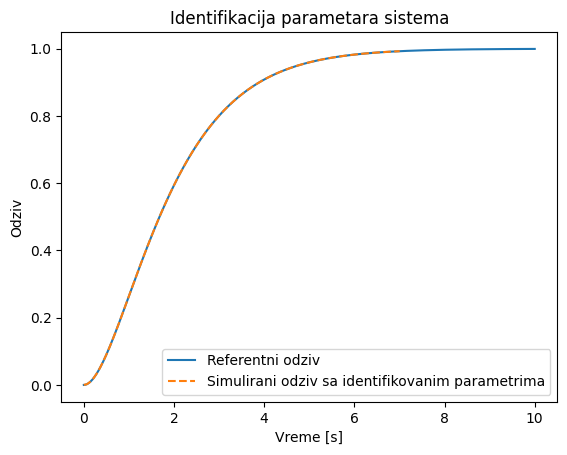

In [15]:
import matplotlib.pyplot as plt

# Simulacija sistema sa identifikovanim parametrima
system_opt = lti([1], [a2_opt, a1_opt, a0_opt])
t_sim, y_sim = step(system_opt)

t_ref, y_ref = reference_response()

# Vizualizacija
plt.plot(t_ref, y_ref, label="Referentni odziv")
plt.plot(t_sim, y_sim, label="Simulirani odziv sa identifikovanim parametrima", linestyle='--')
plt.xlabel("Vreme [s]")
plt.ylabel("Odziv")
plt.legend()
plt.title("Identifikacija parametara sistema")
plt.show()

# Optimizacija hiperparametara neuronskih mreža primenom celobrojnog PSO algoritma

Koliko dobro neuronska mreža modeluje podatke zavisi, ne samo od toga kako je obučena, već i od same arhitekture mreže, odnosno broja slojeva i broja neurona u skrivenim slojevima. Jedan od načina da se optimizuje broj neurona u skrivenom sloju je primena celobrojnog PSO algoritma, odnosno PSO algoritma gde se pozicije zaokružuju na cele brojeve, zato što broj neurona mora biti ceo broj. U nastavku je dat primer određivanja broja neurona u dva skrivena sloja. Pored ove modifikacije, koristi se i kaznena funkcija, koja kažnjava kriterijum optimalnosti ako je predložen negativan broj neurona i to tako što postavi vrednost kriterijuma optimalnosti na neki veliki broj, u ovom slučaju 99999999. Za implementaciju veštačke neuronske mreže, koristi se Python paket tensorflow.

In [16]:
# Load basic numeric packages
import numpy as np
import random as random
import math as math
import matplotlib.pyplot as plt

In [17]:
#This class defines default values of the options within the options structure.
class myOptions:
    def __init__(self):
        self.npart          = 30;       # The number of particles.
        self.niter          = 100;      # The number of iterations.
        self.cbi            = 2.5;      # Initial value of the individual-best acceleration factor.
        self.cbf            = 0.5;      # Final value of the individual-best acceleration factor.
        self.cgi            = 0.5;      # Initial value of the global-best acceleration factor.
        self.cgf            = 2.5;      # Final value of the global-best acceleration factor.
        self.wi             = 0.9;      # Initial value of the inertia factor.
        self.wf             = 0.4;      # Final value of the inertia factor.
        self.vmax           = math.inf;      # Absolute speed limit. It is the primary speed limit.
        self.vmaxscale      = float('nan');      #Relative speed limit. Used only if absolute limit is unspecified.
        self.vspaninit      = 1;        # The initial velocity span. Initial velocities are initialized
        self.initpopulation = float('nan');
        self.initoffset     = 0;        # Offset of the initial population.
        self.initspan       = 1;        # Span of the initial population.
        self.trustoffset    = 0;        # If set to 1 (true) and offset is vector, than the offset is
                                # believed to be a good solution candidate, so it is included in
                                # the initial swarm.

In [18]:
class Error(Exception):
    def __init__(self, message):
        self.message = message

In [19]:
class Particle_integer:
    def __init__(self,x0,num_dimensions,options):
        self.position_i=[]          # particle position
        self.velocity_i=[]          # particle velocity
        self.pos_best_i=[]          # best position individual
        self.fitness_best_i=-1          # best fitness individual
        self.fitness_i=-1               # fitness individual
        self.num_dimensions=num_dimensions

        # Initial positions and velocities
        for i in range(0,num_dimensions):
            self.velocity_i.append((np.random.randint(-1,1)-0.5)*2*options.vspaninit)
            self.position_i.append(x0[i][0])

    # calculate current fitness and alculating new individually best values
    def evaluate(self,costFunc):
        self.fitness_i=costFunc(self.position_i)
        # upadete individual best -> check to see if the current position is better than an individual best
        if self.fitness_i < self.fitness_best_i or self.fitness_best_i==-1:
            self.pos_best_i=np.copy(self.position_i)
            self.fitness_best_i=np.copy(self.fitness_i)


    def linrate(self,xmax, xmin, tmax, tmin, t):
        x = xmin + ((xmax-xmin)/(tmax-tmin))*(tmax-t)
        return x

    # update new particle velocity
    def update_velocity(self,pos_best_g,maxiter,iter,opt):

        # Calculating PSO parameters
        w = self.linrate(opt.wf, opt.wi, maxiter, 0, iter);
        cp = self.linrate(opt.cbf, opt.cbi, maxiter, 0, iter);
        cg = self.linrate(opt.cgf, opt.cgi, maxiter, 0, iter);


        for i in range(0,self.num_dimensions):
            r1=random.random()
            r2=random.random()
            # Calculating speeds
            vel_cognitive=cp*r1*(self.pos_best_i[i]-self.position_i[i])
            vel_social=cg*r2*(pos_best_g[i]-self.position_i[i])
            self.velocity_i[i]=w*self.velocity_i[i]+vel_cognitive+vel_social

    # update the particle position based off new velocity updates->moving particle
    def update_position(self):
        for i in range(0,self.num_dimensions):
            self.position_i[i]=np.round(self.position_i[i]+self.velocity_i[i]).astype(int)

In [20]:
class PSO_integer():
    def __init__(self,costFunc,num_dimensions,options):
        self.pos_best_g=[]
        self.fitness_best_g=-1
        fitness_best_g=-1                   # best fitness in population
        pos_best_g=[]                      # best position in population

        maxiter=options.niter
        num_particles=options.npart
        population=[]
        if ((~np.isnan(options.initpopulation)).all()):
            b=np.shape(options.initpopulation)
            if(np.size(b)==1):
                pno=b[0]
                pdim=1
            if (pno!=options.npart) or (pdim!=options.nvar):
                 raise Error("The format of initial population is inconsistent with desired population")
            population=options.initpopulation;
        else:
            for i in range(0,num_particles):
                x0=np.round( (np.random.randint(-1,1,(num_dimensions,1))*options.initspan + options.initoffset)).astype(int)
                population.append(Particle_integer(x0,num_dimensions,options))

        #################################
        ###The main loop  ###############
        #################################
        # Begin optimization loop
        i=0
        while i < maxiter:
            print(i,fitness_best_g)
            # cycle through particles in swarm and evaluate fitness
            for j in range(0,num_particles):
                population[j].evaluate(costFunc)

                # Calculating new globally best values (globally)
                if population[j].fitness_i < fitness_best_g or fitness_best_g == -1:
                    pos_best_g=list(population[j].position_i)
                    fitness_best_g=float(population[j].fitness_i)

            # Population is moving-> cycle through population and update velocities and position
            for j in range(0,num_particles):
                population[j].update_velocity(pos_best_g,maxiter,i,options)
                population[j].update_position()
            i+=1
         #   print( pos_best_g)
        # print final results
        print( 'Optimal point:')
        print( pos_best_g)
        print( 'Optimal value:')
        print (fitness_best_g)
        self.pos_best_g=pos_best_g
        self.fitness_best_g=fitness_best_g

In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np


# Podatke veštački generišemo, uzmemo neke vrednosti za x,
#izračunamo kolika bi bila vrednost izlaza iz funcije za te vrednosti dodamo malo "šuma" na to
# sa ovim np.random.randn
np.random.seed(42)
X = np.random.rand(100, 1)  # One feature for simplicity
y = 3 * X.squeeze() + 2 + 0.1 * np.random.randn(100)  # Linear relation with some noise

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def build_model(params):
    #print(params)


    model = Sequential()
    model.add(Dense(params[0], input_dim=X_train.shape[1], activation='relu'))
    model.add(Dense(params[1], activation='relu'))
    model.add(Dense(1, activation='linear'))
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

    #model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
             #     loss='mse',
             #     metrics=['accuracy'])
    return model

# Define the objective function for PSO
def objective_function(params):
  #print(params)
  if any(element < 1 for element in params):
    return 99999999

  model = build_model(params)
  model.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test), verbose=0)
  loss, mae = model.evaluate(X_test, y_test)
  return mae  # PSO minimizes the objective function, so we use negative accuracy



# Perform PSO optimization

options1 = myOptions()
options1.npart=10
options1.niter=10
options1.initspan=40

best_params=PSO_integer(objective_function,2,options=options1)
print(best_params.pos_best_g)

print(best_params.fitness_best_g)
if any(element < 1 for element in best_params.pos_best_g):
  print('Nije nadjeno resenje')
else:
# #print(acc)
# #best_params, _ = pso(objective_function, lb, ub, swarmsize=10, maxiter=10)

# # Print the best hyperparameters found
  print("Best Hyperparameters:")
  print("Number of neurons in the first layer:", int(best_params.pos_best_g[0]))
  print("Number of neurons in the second layer:", int(best_params.pos_best_g[1]))




ModuleNotFoundError: No module named 'tensorflow'

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


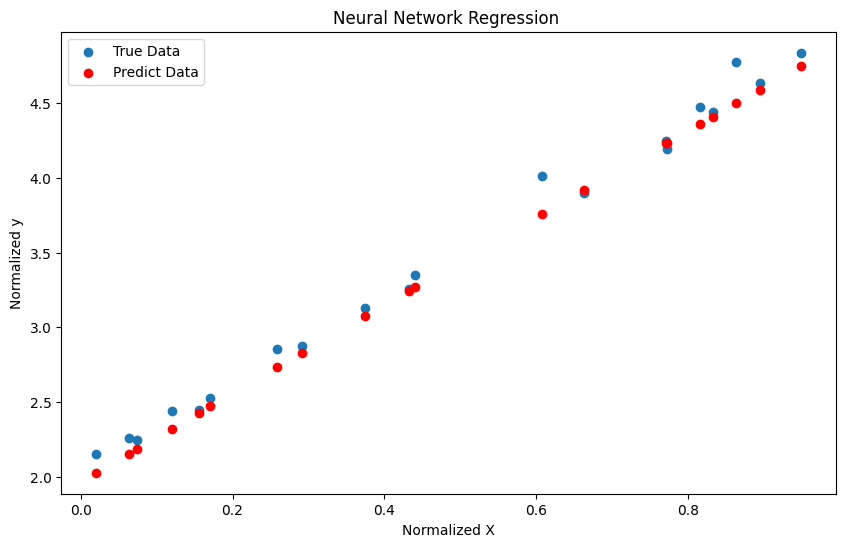

In [ ]:
final_model = build_model(best_params.pos_best_g)
final_model.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test), verbose=0)
y_pred = final_model.predict(X_test)
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, label='True Data')
plt.scatter(X_test, y_pred, label='Predict Data',c='red')

plt.title('Neural Network Regression ')
plt.xlabel('Normalized X')
plt.ylabel('Normalized y')
plt.legend()
plt.show()